# PROJECT NLP & INFORMATION RETRIEVAL BY BOULMIER Ilan & COLIN De Verdière Thomas 

## PARTIE I : EXPLORATION 
Cette partie couvre :

1. Chargement et fusion des 35 fichiers Excel
2. Vue d'ensemble du dataset
3. Visualisations (distribution des notes, assureurs, types)
4. Premières conclusions

### 0. Imports et configuration

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
import zipfile
warnings.filterwarnings('ignore')

# Style général
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('Imports OK')

Imports OK


### 1. Chargement des données

In [2]:

ZIP_PATH = 'Traduction avis clients.zip'  # chemin vers ton zip

dfs = []
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    for filename in sorted(z.namelist()):
        if filename.endswith('.xlsx'):
            with z.open(filename) as f:
                df = pd.read_excel(f)
                df['source_file'] = filename
                dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
print(f' {len(dfs)} fichiers chargés')
print(f' {len(df_all):,} avis au total')

 35 fichiers chargés
 34,435 avis au total


### 2. Vue d'ensemble du dataset

In [3]:
print('=== FORME DU DATASET ===')
print(f'Lignes : {df_all.shape[0]:,}')
print(f'Colonnes : {df_all.shape[1]}')
print()
print('=== TYPES DES COLONNES ===')
print(df_all.dtypes)
print()
print('=== VALEURS MANQUANTES ===')
missing = df_all.isnull().sum()
missing_pct = (missing / len(df_all) * 100).round(2)
missing_df = pd.DataFrame({'Manquantes': missing, 'Pourcentage (%)': missing_pct})
print(missing_df[missing_df['Manquantes'] > 0])

=== FORME DU DATASET ===
Lignes : 34,435
Colonnes : 12

=== TYPES DES COLONNES ===
note                float64
auteur               object
avis                 object
assureur             object
produit              object
type                 object
date_publication     object
date_exp             object
avis_en              object
avis_cor             object
avis_cor_en          object
source_file          object
dtype: object

=== VALEURS MANQUANTES ===
             Manquantes  Pourcentage (%)
note              10331            30.00
auteur                1             0.00
avis_en               2             0.01
avis_cor          34000            98.74
avis_cor_en       34004            98.75


### 2.1 Séparation train/test

In [4]:
# Séparation train / test
df_train = df_all[df_all['type'] == 'train'].copy()
df_test  = df_all[df_all['type'] == 'test'].copy()

print(f'Train : {len(df_train):,} avis (avec note)')
print(f'Test  : {len(df_test):,} avis (sans note)')
print()
print('Statistiques sur les notes (train) :')
print(df_train['note'].describe())

Train : 24,104 avis (avec note)
Test  : 10,331 avis (sans note)

Statistiques sur les notes (train) :
count    24104.000000
mean         2.847619
std          1.531390
min          1.000000
25%          1.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: note, dtype: float64


### 3. Visualisations

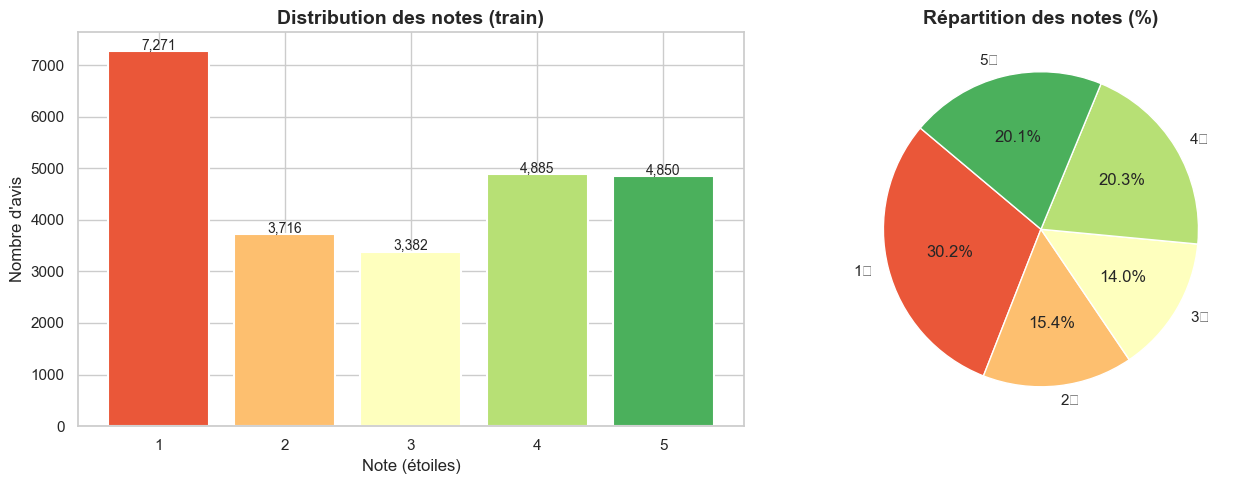

💾 Sauvegardé : distribution_notes.png


In [6]:
# --- Distribution des notes ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
note_counts = df_train['note'].value_counts().sort_index()
axes[0].bar(note_counts.index.astype(int), note_counts.values,
            color=sns.color_palette('RdYlGn', 5), edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution des notes (train)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Note (étoiles)')
axes[0].set_ylabel('Nombre d\'avis')
for i, (note, count) in enumerate(note_counts.items()):
    axes[0].text(note, count + 30, f'{count:,}', ha='center', fontsize=10)

# Pie chart
colors = sns.color_palette('RdYlGn', 5)
axes[1].pie(note_counts.values, labels=[f'{int(n)}⭐' for n in note_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Répartition des notes (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribution_notes.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Sauvegardé : distribution_notes.png')

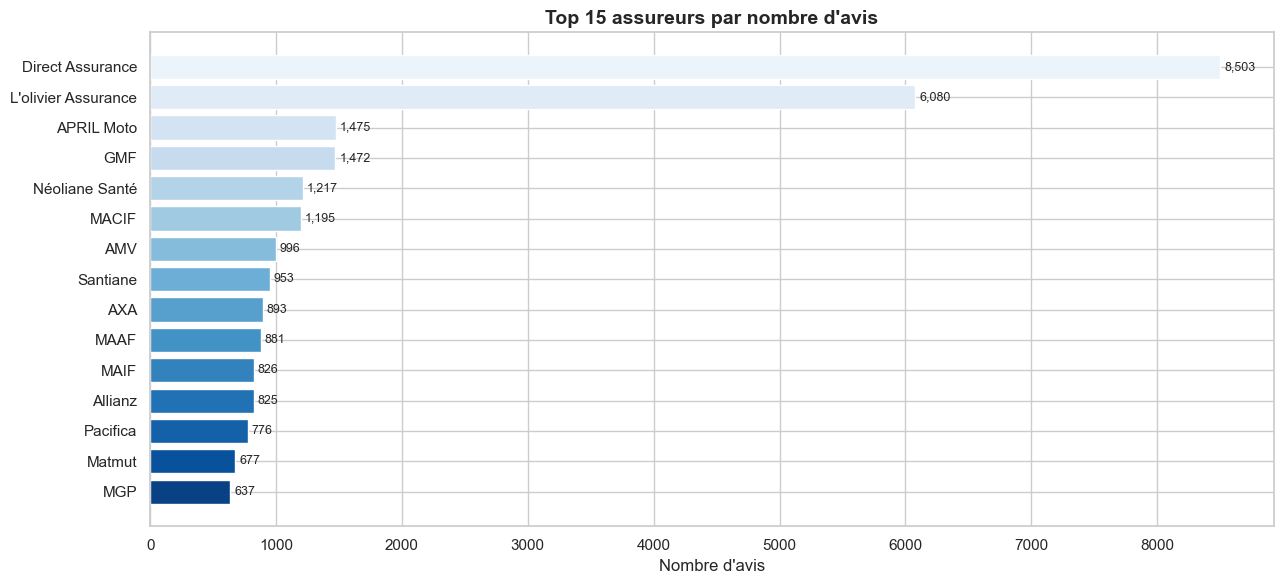

In [7]:
# --- Top 15 assureurs par nombre d'avis ---
top_assureurs = df_all['assureur'].value_counts().head(15)

plt.figure(figsize=(13, 6))
bars = plt.barh(top_assureurs.index[::-1], top_assureurs.values[::-1],
                color=sns.color_palette('Blues_r', 15))
plt.title('Top 15 assureurs par nombre d\'avis', fontsize=14, fontweight='bold')
plt.xlabel('Nombre d\'avis')
for bar, val in zip(bars, top_assureurs.values[::-1]):
    plt.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_assureurs.png', dpi=150, bbox_inches='tight')
plt.show()

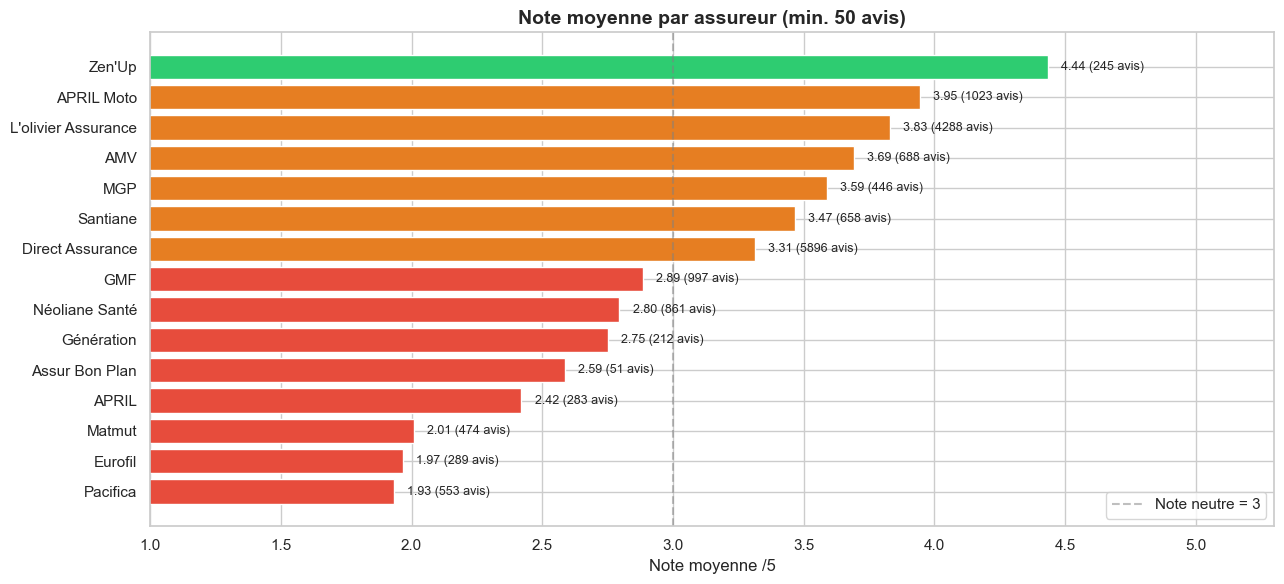

In [8]:
# --- Note moyenne par assureur (top 15) ---
note_par_assureur = (
    df_train.groupby('assureur')['note']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'note_moyenne', 'count': 'nb_avis'})
    .query('nb_avis >= 50')  # Filtrer les assureurs avec trop peu d'avis
    .sort_values('note_moyenne', ascending=False)
    .head(15)
)

plt.figure(figsize=(13, 6))
colors = ['#2ecc71' if n >= 4 else '#e67e22' if n >= 3 else '#e74c3c'
          for n in note_par_assureur['note_moyenne'][::-1]]
plt.barh(note_par_assureur.index[::-1], note_par_assureur['note_moyenne'][::-1],
         color=colors)
plt.axvline(x=3, color='gray', linestyle='--', alpha=0.5, label='Note neutre = 3')
plt.title('Note moyenne par assureur (min. 50 avis)', fontsize=14, fontweight='bold')
plt.xlabel('Note moyenne /5')
plt.xlim(1, 5.3)
for i, (idx, row) in enumerate(note_par_assureur[::-1].iterrows()):
    plt.text(row['note_moyenne'] + 0.05, i,
             f"{row['note_moyenne']:.2f} ({int(row['nb_avis'])} avis)",
             va='center', fontsize=9)
plt.legend()
plt.tight_layout()
plt.savefig('notes_par_assureur.png', dpi=150, bbox_inches='tight')
plt.show()

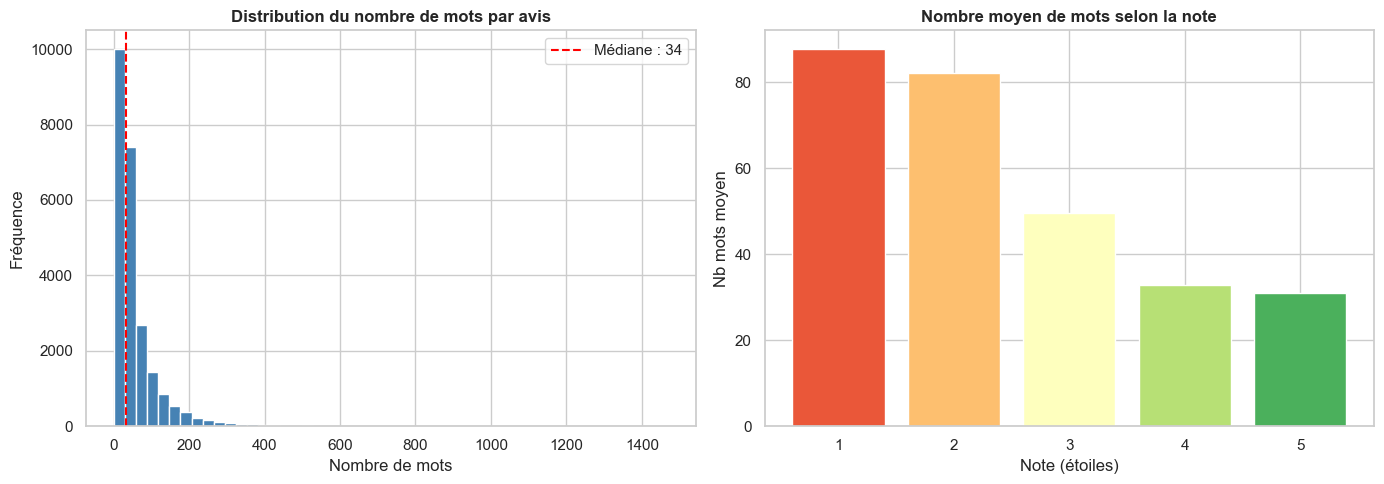

       nb_mots  longueur_avis
count  24104.0        24104.0
mean      59.0          348.5
std       68.0          393.5
min        1.0            3.0
25%       27.0          162.0
50%       34.0          201.0
75%       66.0          385.0
max     1469.0         8770.0


In [9]:
# --- Longueur des avis ---
df_train['longueur_avis'] = df_train['avis'].str.len()
df_train['nb_mots'] = df_train['avis'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_train['nb_mots'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du nombre de mots par avis', fontweight='bold')
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(df_train['nb_mots'].median(), color='red', linestyle='--',
                label=f"Médiane : {df_train['nb_mots'].median():.0f}")
axes[0].legend()

# Longueur moyenne par note
mots_par_note = df_train.groupby('note')['nb_mots'].mean()
axes[1].bar(mots_par_note.index.astype(int), mots_par_note.values,
            color=sns.color_palette('RdYlGn', 5))
axes[1].set_title('Nombre moyen de mots selon la note', fontweight='bold')
axes[1].set_xlabel('Note (étoiles)')
axes[1].set_ylabel('Nb mots moyen')

plt.tight_layout()
plt.savefig('longueur_avis.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_train[['nb_mots', 'longueur_avis']].describe().round(1))

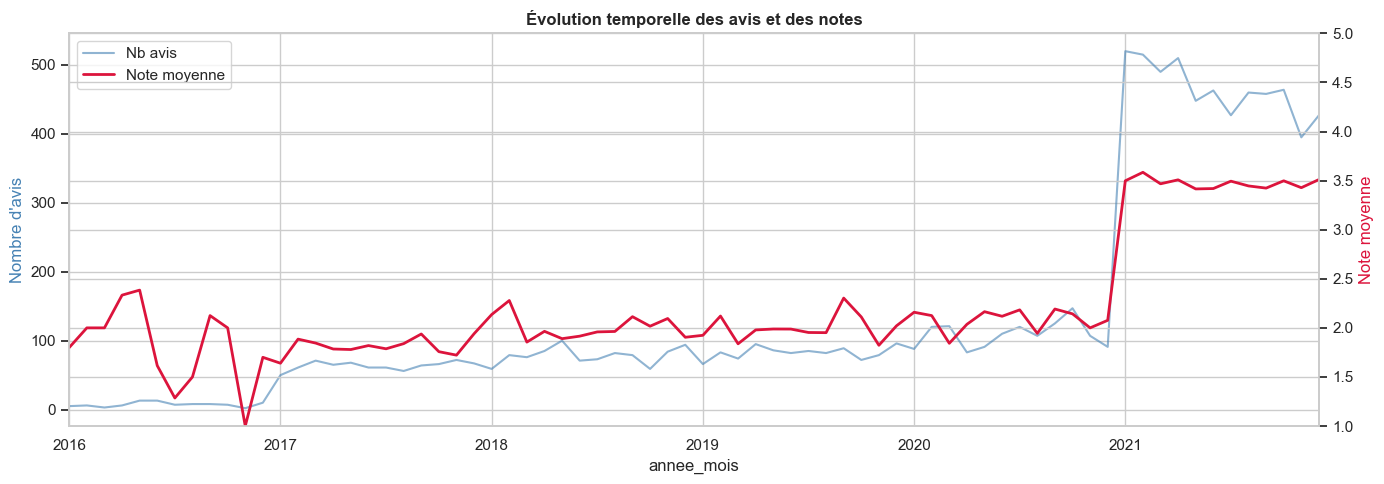

In [10]:
# --- Evolution temporelle ---
df_train['date_publication'] = pd.to_datetime(df_train['date_publication'], errors='coerce')
df_train['annee_mois'] = df_train['date_publication'].dt.to_period('M')

avis_par_mois = df_train.groupby('annee_mois').size()
note_par_mois = df_train.groupby('annee_mois')['note'].mean()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

avis_par_mois.plot(ax=ax1, color='steelblue', alpha=0.6, label='Nb avis')
note_par_mois.plot(ax=ax2, color='crimson', linewidth=2, label='Note moyenne')

ax1.set_ylabel('Nombre d\'avis', color='steelblue')
ax2.set_ylabel('Note moyenne', color='crimson')
ax2.set_ylim(1, 5)
ax1.set_title('Évolution temporelle des avis et des notes', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('evolution_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
print('=' * 60)
print('CONCLUSIONS/RESUME GENERALES')
print('=' * 60)
print(f"""
1. TAILLE DU DATASET
   - {len(df_all):,} avis clients au total
   - {len(df_train):,} avis étiquetés (train)
   - {len(df_test):,} avis non étiquetés (test)
   - 56 assureurs différents

2. DÉSÉQUILIBRE DES CLASSES
   - Les notes 1 et 5 sont surreprésentées
   - Note 3 (neutre) est la moins fréquente
   → Attention : les modèles ML peuvent biaiser vers 1 et 5
   → Stratégie : class_weight='balanced' ou oversampling

3. LONGUEUR DES AVIS
   - Médiane ~{df_train['nb_mots'].median():.0f} mots par avis
   - Les avis négatifs (1★) tendent à être plus longs
   - Forte variance : certains avis = 1 mot, d'autres > 500 mots

4. QUALITÉ DES DONNÉES
   - Colonnes 'avis_cor' et 'avis_cor_en' très peu remplies (~1%)
   - Colonne 'avis_en' : traduction anglaise disponible pour ~100%
   - Quelques doublons potentiels à vérifier

5. PISTES POUR LES MODÈLES
   - Tâche principale : prédire la note (1-5) → classification 5 classes
   - Possible simplification : 3 sentiments (négatif/neutre/positif)
   - Travailler sur l'avis FR, EN, ou les deux
""")

CONCLUSIONS/RESUME GENERALES

1. TAILLE DU DATASET
   - 34,435 avis clients au total
   - 24,104 avis étiquetés (train)
   - 10,331 avis non étiquetés (test)
   - 56 assureurs différents

2. DÉSÉQUILIBRE DES CLASSES
   - Les notes 1 et 5 sont surreprésentées
   - Note 3 (neutre) est la moins fréquente
   → Attention : les modèles ML peuvent biaiser vers 1 et 5
   → Stratégie : class_weight='balanced' ou oversampling

3. LONGUEUR DES AVIS
   - Médiane ~34 mots par avis
   - Les avis négatifs (1★) tendent à être plus longs
   - Forte variance : certains avis = 1 mot, d'autres > 500 mots

4. QUALITÉ DES DONNÉES
   - Colonnes 'avis_cor' et 'avis_cor_en' très peu remplies (~1%)
   - Colonne 'avis_en' : traduction anglaise disponible pour ~100%
   - Quelques doublons potentiels à vérifier

5. PISTES POUR LES MODÈLES
   - Tâche principale : prédire la note (1-5) → classification 5 classes
   - Possible simplification : 3 sentiments (négatif/neutre/positif)
   - Travailler sur l'avis FR, EN, o

In [14]:
# Sauvegarder le dataset fusionné pour les prochains notebooks
df_all.to_csv('avis_all.csv', index=False)
df_train.to_csv('avis_train.csv', index=False)
df_test.to_csv('avis_test.csv', index=False)
print('✅ Datasets sauvegardés :')
print('   - data/avis_all.csv')
print('   - data/avis_train.csv')
print('   - data/avis_test.csv')

✅ Datasets sauvegardés :
   - data/avis_all.csv
   - data/avis_train.csv
   - data/avis_test.csv
